In [ ]:
# Install required packages

!pip install kaggle xgboost scikit-learn imbalanced-learn matplotlib seaborn

In [ ]:
# Including Important Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, precision_score, recall_score
)
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Uploading the Kaggle API credentials

from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vaibhavkhanna007","key":"428675ab6293115a923d51de9d52f910"}'}

In [ ]:
# Moving kaggle.json to the proper location

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Downloading the DataSet

!kaggle datasets download -d rupakroy/online-payments-fraud-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset
License(s): CC-BY-NC-SA-4.0


In [ ]:
# Unzipping The Dataset

!unzip online-payments-fraud-detection-dataset.zip

Archive:  online-payments-fraud-detection-dataset.zip
  inflating: PS_20174392719_1491204439457_log.csv  


In [ ]:
# Loading the dataset

df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# Checking the columns

print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [ ]:
# Checking class distribution

print('Class distribution:')
print(df['isFraud'].value_counts())

Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


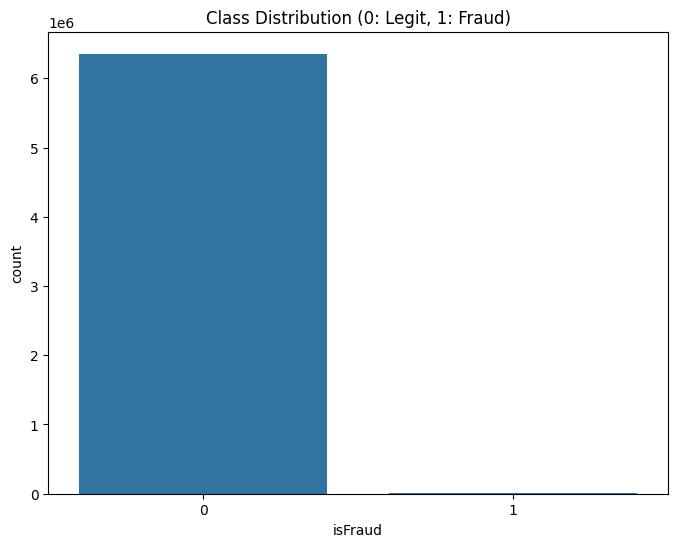

In [ ]:
# Visualizing class distribution

plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df)
plt.title('Class Distribution (0: Legit, 1: Fraud)')
plt.show()

In [ ]:
# Checking missing values

print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:

# Droping irrelevant columns (IDs, names)

df = df.drop(columns=['nameOrig', 'nameDest'])

In [ ]:
# One-hot encode categorical 'type'

df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
# Seperating Features and target

X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [ ]:
# Splitting the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Standardizing the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Undersample to balance the classes

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_scaled, y_train)

In [ ]:
# Verifying balance

print('Resampled class distribution:')
print(pd.Series(y_train_resampled).value_counts())

Resampled class distribution:
isFraud
0    6570
1    6570
Name: count, dtype: int64


In [ ]:
# Storing Model performance

model_performance = {}

In [ ]:
# Function to print evaluation metrics

def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n{model_name} - Evaluation Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR AUC: {average_precision_score(y_test, y_prob):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


In [ ]:
# Applying Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
evaluate_model(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression')
model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr),
    'ROC AUC': roc_auc_score(y_test, y_prob_lr),
    'PR AUC': average_precision_score(y_test, y_prob_lr)
}


Logistic Regression - Evaluation Metrics:
Accuracy: 0.9295
Precision: 0.0168
Recall: 0.9337
F1 Score: 0.0331
ROC AUC: 0.9843
PR AUC: 0.5578
Confusion Matrix:
[[1181324   89557]
 [    109    1534]]


In [ ]:
# Applying Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
evaluate_model(y_test, y_pred_rf, y_prob_rf, 'Random Forest')
model_performance['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'ROC AUC': roc_auc_score(y_test, y_prob_rf),
    'PR AUC': average_precision_score(y_test, y_prob_rf)
}


Random Forest - Evaluation Metrics:
Accuracy: 0.9870
Precision: 0.0900
Recall: 0.9957
F1 Score: 0.1650
ROC AUC: 0.9995
PR AUC: 0.8537
Confusion Matrix:
[[1254332   16549]
 [      7    1636]]


In [ ]:
# Applying XGBoost Classifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
evaluate_model(y_test, y_pred_xgb, y_prob_xgb, 'XGBoost')
model_performance['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb),
    'ROC AUC': roc_auc_score(y_test, y_prob_xgb),
    'PR AUC': average_precision_score(y_test, y_prob_xgb)
}


XGBoost - Evaluation Metrics:
Accuracy: 0.9911
Precision: 0.1260
Recall: 0.9982
F1 Score: 0.2238
ROC AUC: 0.9997
PR AUC: 0.9042
Confusion Matrix:
[[1259510   11371]
 [      3    1640]]


In [ ]:
# Applying Isolation Forest

iso_forest = IsolationForest(n_estimators=100, contamination=float(len(y_train[y_train==1]))/len(y_train), random_state=42)
iso_forest.fit(X_train_scaled)
y_pred_iso = iso_forest.predict(X_test_scaled)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]
evaluate_model(y_test, y_pred_iso, y_pred_iso, 'Isolation Forest')
model_performance['Isolation Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_iso),
    'Precision': precision_score(y_test, y_pred_iso),
    'Recall': recall_score(y_test, y_pred_iso),
    'F1 Score': f1_score(y_test, y_pred_iso),
    'ROC AUC': roc_auc_score(y_test, y_pred_iso),
    'PR AUC': average_precision_score(y_test, y_pred_iso)
}


Isolation Forest - Evaluation Metrics:
Accuracy: 0.9975
Precision: 0.0222
Recall: 0.0219
F1 Score: 0.0221
ROC AUC: 0.5103
PR AUC: 0.0018
Confusion Matrix:
[[1269299    1582]
 [   1607      36]]


In [ ]:
# Importing KMeans

from sklearn.cluster import KMeans

# Applying K-Means Clustering

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled)
y_pred_kmeans = kmeans.predict(X_test_scaled)


# Determining which cluster is fraud (based on majority)

cluster_labels = pd.DataFrame({'Cluster': y_pred_kmeans, 'TrueLabel': y_test})
fraud_cluster = cluster_labels.groupby('Cluster')['TrueLabel'].mean().idxmax()
y_pred_kmeans_binary = [1 if label == fraud_cluster else 0 for label in y_pred_kmeans]
evaluate_model(y_test, y_pred_kmeans_binary, y_pred_kmeans_binary, 'K-Means Clustering')
model_performance['K-Means Clustering'] = {
    'Accuracy': accuracy_score(y_test, y_pred_kmeans_binary),
    'Precision': precision_score(y_test, y_pred_kmeans_binary),
    'Recall': recall_score(y_test, y_pred_kmeans_binary),
    'F1 Score': f1_score(y_test, y_pred_kmeans_binary),
    'ROC AUC': roc_auc_score(y_test, y_pred_kmeans_binary),
    'PR AUC': average_precision_score(y_test, y_pred_kmeans_binary)
}


K-Means Clustering - Evaluation Metrics:
Accuracy: 0.9118
Precision: 0.0085
Recall: 0.5825
F1 Score: 0.0168
ROC AUC: 0.7473
PR AUC: 0.0055
Confusion Matrix:
[[1159286  111595]
 [    686     957]]


In [ ]:

# Converting to DataFrame for comparison

performance_df = pd.DataFrame(model_performance).T
print("\nModel Performance Summary:")
print(performance_df)



Model Performance Summary:
                     Accuracy  Precision    Recall  F1 Score   ROC AUC  \
Logistic Regression  0.929537   0.016840  0.933658  0.033084  0.984286   
Random Forest        0.986990   0.089964  0.995740  0.165019  0.999471   
XGBoost              0.991062   0.126047  0.998174  0.223830  0.999676   
Isolation Forest     0.997494   0.022250  0.021911  0.022079  0.510333   
K-Means Clustering   0.911765   0.008503  0.582471  0.016761  0.747331   

                       PR AUC  
Logistic Regression  0.557778  
Random Forest        0.853683  
XGBoost              0.904153  
Isolation Forest     0.001750  
K-Means Clustering   0.005492  


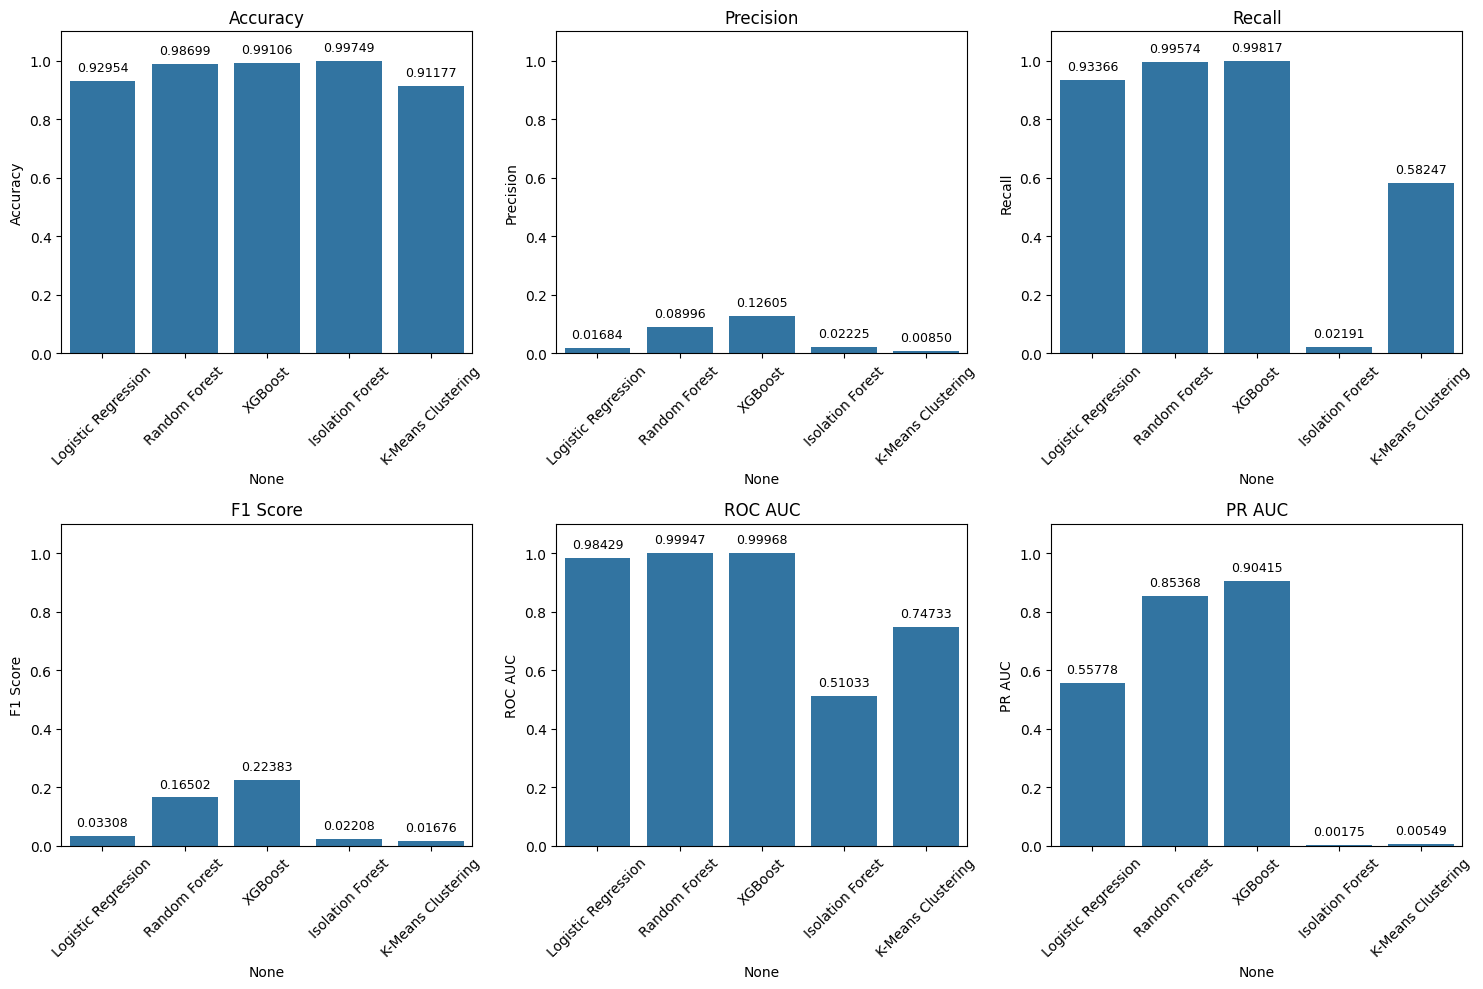

In [ ]:
# Plot Evaluation Metrics

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC']

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    ax = sns.barplot(x=performance_df.index, y=performance_df[metric])
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.ylim(0, 1.1)

    # Adding labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.5f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()